In [49]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OrdinalEncoder
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV


### 1 — Data loading and inspection
The datasets are here: https://dbdmg.polito.it/dbdmg_web/wp-content/uploads/2025/11/Lab-05-Regression-Exam-Simulation.zip
Tasks:
- Load `dev.csv` and `test.csv`.
- Print shape, columns, dtypes, head, and missing-value summary.


(Implement your code in the cell below.)

In [50]:
train_data  = pd.read_csv('train_dataset.csv')
test_data = pd.read_csv('test_dataset.csv')
test_data.info(), train_data.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 58 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   cont_0   3169 non-null   float64
 1   cont_1   3200 non-null   float64
 2   cont_2   3171 non-null   float64
 3   cont_3   3191 non-null   float64
 4   cont_4   3204 non-null   float64
 5   cont_5   3182 non-null   float64
 6   cont_6   3209 non-null   float64
 7   cont_7   3200 non-null   float64
 8   cont_8   3182 non-null   float64
 9   cont_9   3193 non-null   float64
 10  cont_10  3153 non-null   float64
 11  cont_11  3170 non-null   float64
 12  cont_12  3183 non-null   float64
 13  cont_13  3185 non-null   float64
 14  cont_14  3172 non-null   float64
 15  cont_15  3161 non-null   float64
 16  cont_16  3227 non-null   float64
 17  cont_17  3199 non-null   float64
 18  cont_18  3204 non-null   float64
 19  cont_19  3219 non-null   float64
 20  cont_20  3201 non-null   float64
 21  cont_21  3178 

(None,
             cont_0       cont_1       cont_2       cont_3       cont_4  \
 count  4783.000000  4907.000000  4828.000000  4795.000000  4825.000000   
 mean      0.002885     6.127311    -3.840599     0.020493     1.053304   
 std       0.028612    39.284176     9.386816     0.057177     8.864547   
 min      -0.061316   -97.829996   -24.779900    -0.117823   -20.014123   
 25%      -0.018367   -18.616319   -11.490150    -0.009969    -5.060698   
 50%       0.005142     4.491540    -3.306776     0.023088     1.584892   
 75%       0.024793    33.464490     2.763724     0.064750     7.743455   
 max       0.062289    99.222672    22.545130     0.123786    22.690421   
 
             cont_5       cont_6       cont_7       cont_8       cont_9  ...  \
 count  4796.000000  4822.000000  4819.000000  4833.000000  4795.000000  ...   
 mean     -1.112336 -1776.132609     2.093507    66.235463     0.496568  ...   
 std       7.584984  3013.886878     3.868775   260.162114    14.525437  ...

### 2 — Preprocessing

Tasks:
- Implement numerical, categorical, and ordinal preprocessing functions.
- Make preprocessing deterministic and reusable for `main.py`.

(Implement your code in the cell below.)

In [51]:
print("length of data is ", train_data.shape[0])

print("number of rows with 25% missing data is ", (train_data.isnull().sum(axis= 1) > 0.25 * train_data.shape[1]).sum())
print("number of rows with 50% missing data is ", (train_data.isnull().sum(axis= 1) > 0.5 * train_data.shape[1]).sum())
print("number of rows with 75% missing data is ", (train_data.isnull().sum(axis= 1) > 0.75 * train_data.shape[1]).sum())

length of data is  6000
number of rows with 25% missing data is  1025
number of rows with 50% missing data is  0
number of rows with 75% missing data is  0


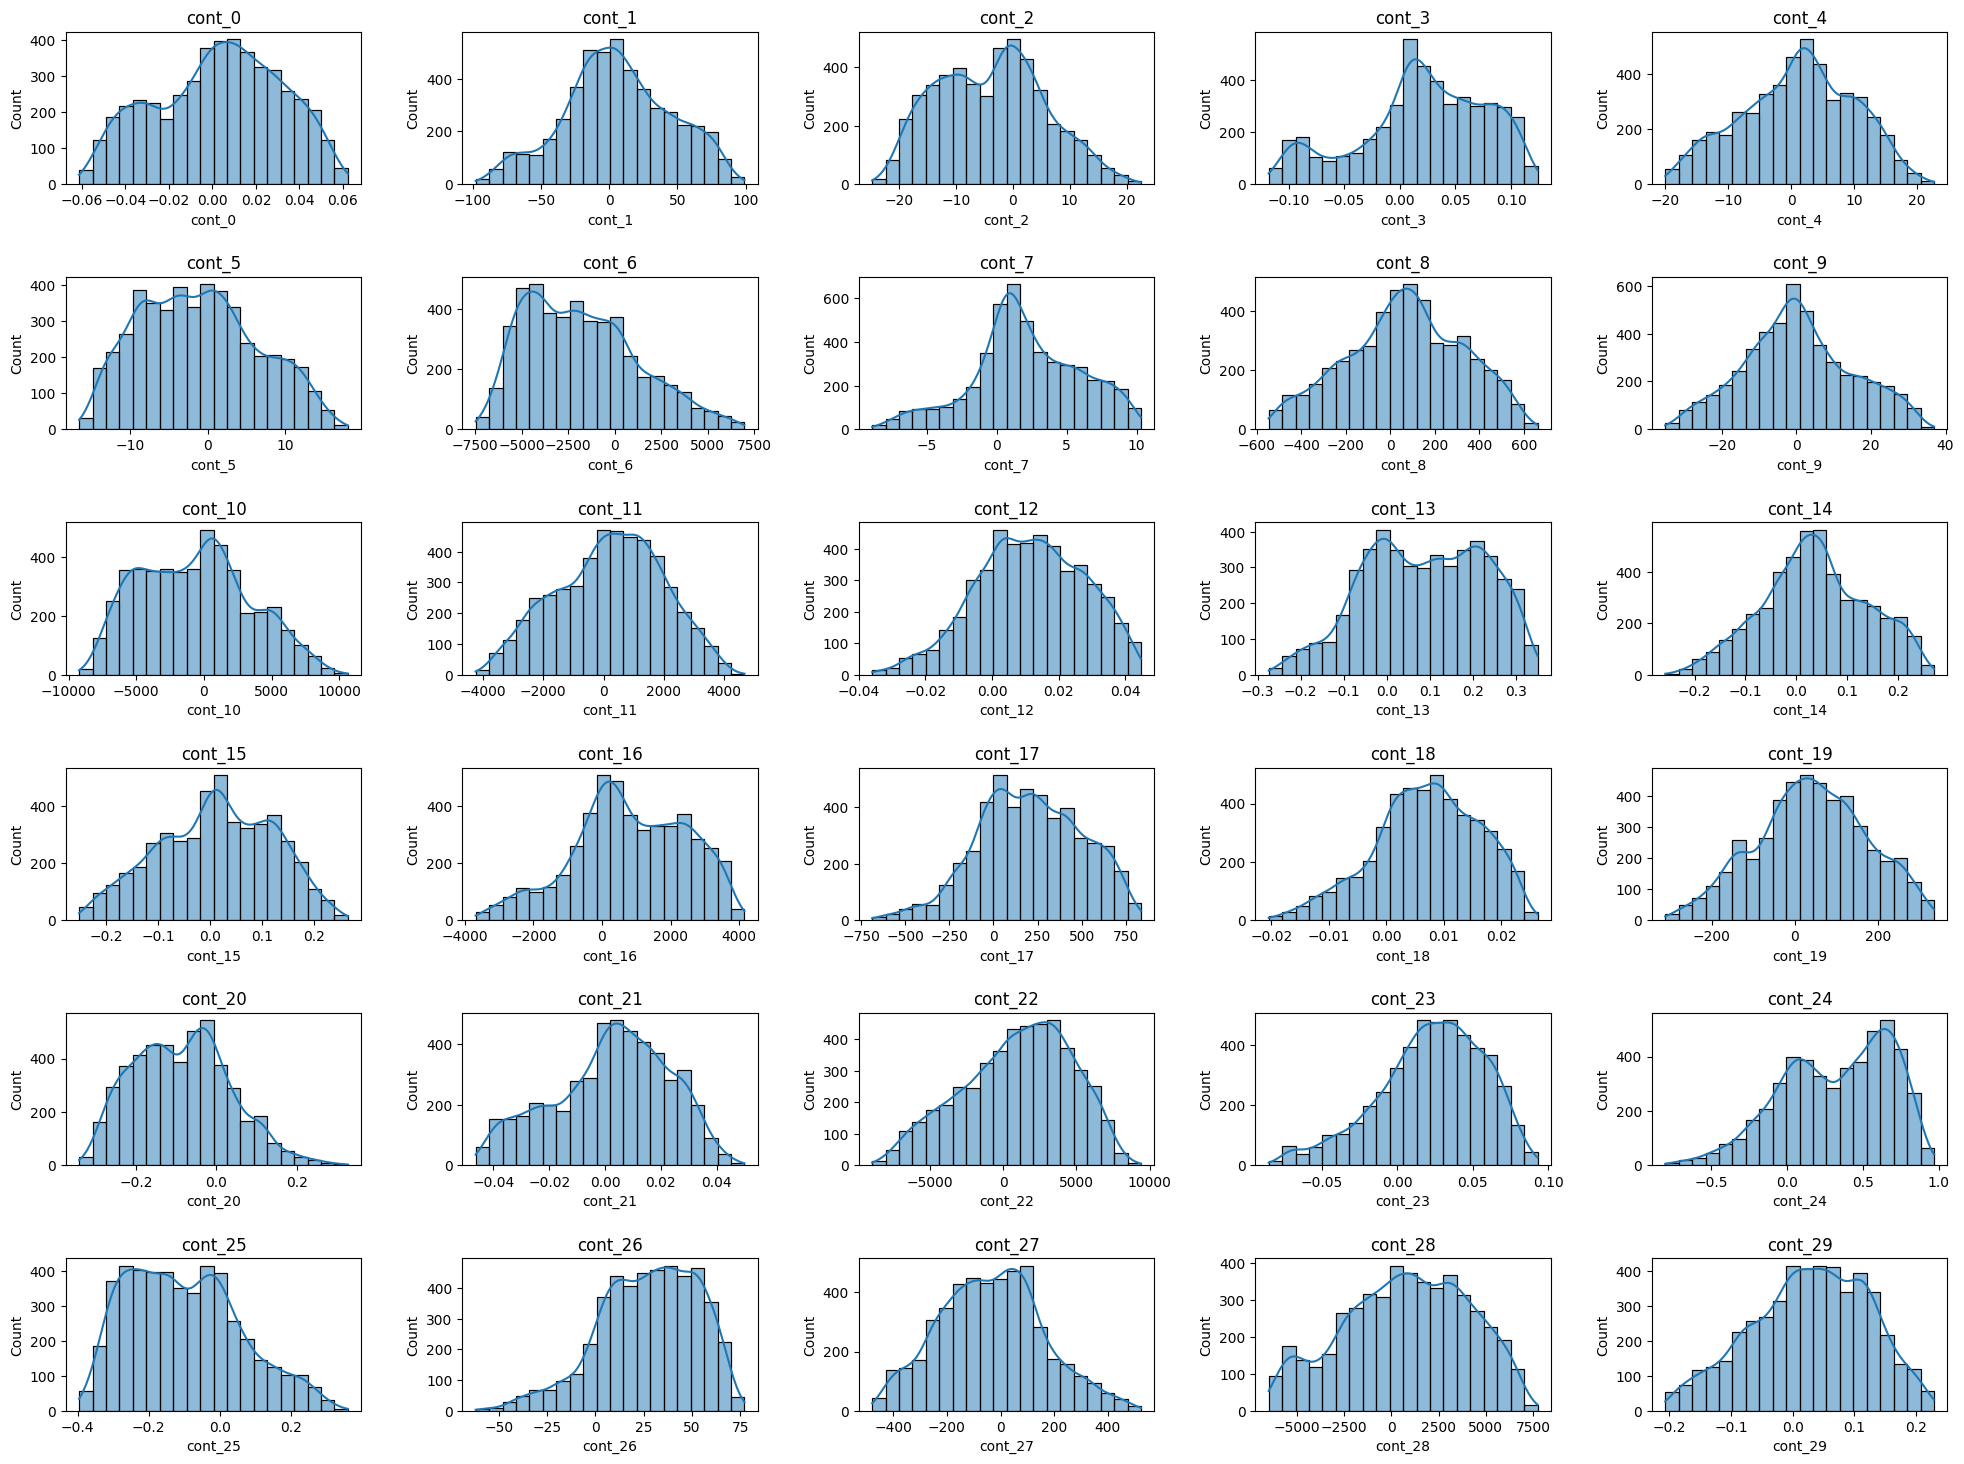

In [52]:
continues_features_mask = [col for col in train_data.columns if 'cont' in col]
train_data[continues_features_mask] = train_data[continues_features_mask]
plt.figure(figsize=(20, 15))

for i, col in enumerate(continues_features_mask):
    plt.subplot(6, 5, i + 1)
    sns.histplot(train_data[col], bins=20, kde=True)
    plt.title(col)

plt.tight_layout(pad=2.0)


In [53]:
scaler = StandardScaler()
train_data[continues_features_mask] = scaler.fit_transform(train_data[continues_features_mask])
test_data[continues_features_mask] = scaler.transform(test_data[continues_features_mask])
train_data[continues_features_mask] = train_data[continues_features_mask].fillna(0)
test_data[continues_features_mask] = test_data[continues_features_mask].fillna(0)
train_data.head()

,cont_0,cont_1,cont_2,cont_3,cont_4,cont_5,cont_6,cont_7,cont_8,cont_9,...,ord_19,cat_0,cat_1,cat_2,cat_3,cat_4,cat_5,cat_6,cat_7,target
0,-1.147122,0.340294,-0.052171,0.000000,-0.841283,-1.498153,0.000000,-0.587915,1.440385,0.000000,...,ord_7_val_5,cat_0_val_9,cat_1_val_2,cat_2_val_1,cat_3_val_10,cat_4_val_0,cat_5_val_0,cat_6_val_0,cat_7_val_1,0.510454
1,0.065070,-0.106847,0.661753,-0.107335,-0.387511,0.482247,0.373006,0.000000,0.000000,0.000000,...,ord_7_val_4,cat_0_val_2,cat_1_val_1,NaN,cat_3_val_9,NaN,cat_5_val_0,cat_6_val_0,cat_7_val_5,-0.476601
2,0.000000,0.324294,0.603764,-0.947736,-0.928576,1.257327,-0.513239,1.152110,-0.782648,0.000000,...,ord_7_val_4,cat_0_val_6,cat_1_val_3,NaN,NaN,cat_4_val_0,cat_5_val_0,cat_6_val_0,cat_7_val_1,-0.918673
3,-0.713981,0.000000,1.458759,0.258885,0.002706,0.792364,0.374375,-1.064428,0.000000,0.729891,...,ord_7_val_4,cat_0_val_2,NaN,cat_2_val_2,cat_3_val_18,NaN,NaN,cat_6_val_0,cat_7_val_5,0.139556
4,0.076516,-0.993449,-0.963134,0.080691,0.000000,0.282438,-0.717418,0.000000,0.407399,0.652549,...,ord_7_val_1,cat_0_val_3,cat_1_val_0,cat_2_val_0,cat_3_val_13,NaN,cat_5_val_0,cat_6_val_0,cat_7_val_3,-1.616743


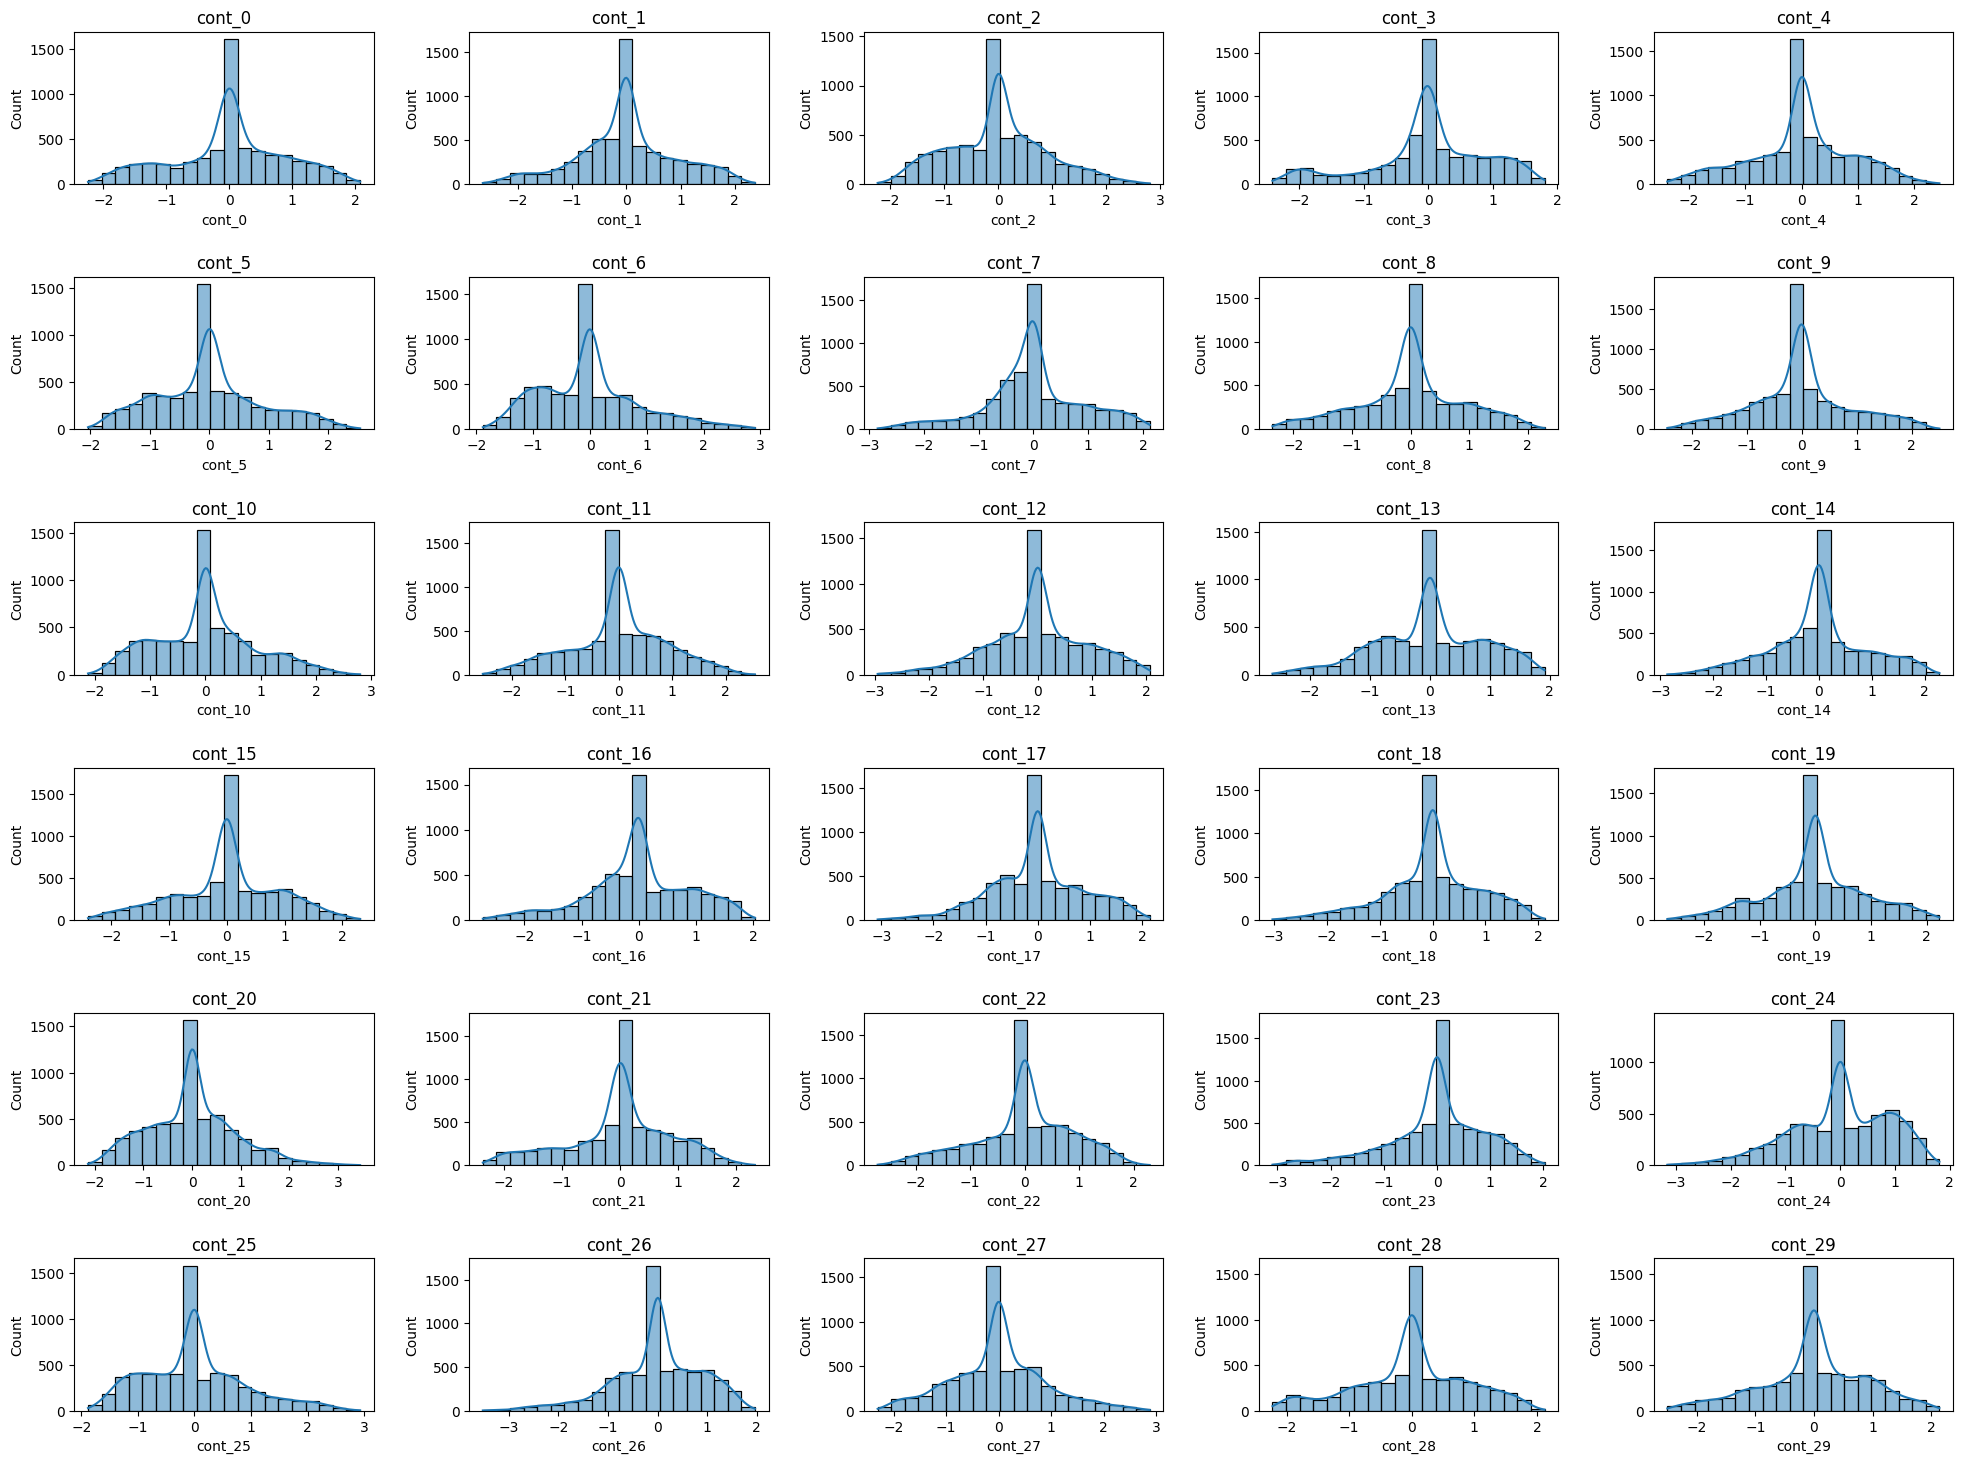

In [54]:
plt.figure(figsize=(20, 15))

for i, col in enumerate(continues_features_mask):
    plt.subplot(6, 5, i + 1)
    sns.histplot(train_data[col], bins=20, kde=True)
    plt.title(col)

plt.tight_layout(pad=2.0)


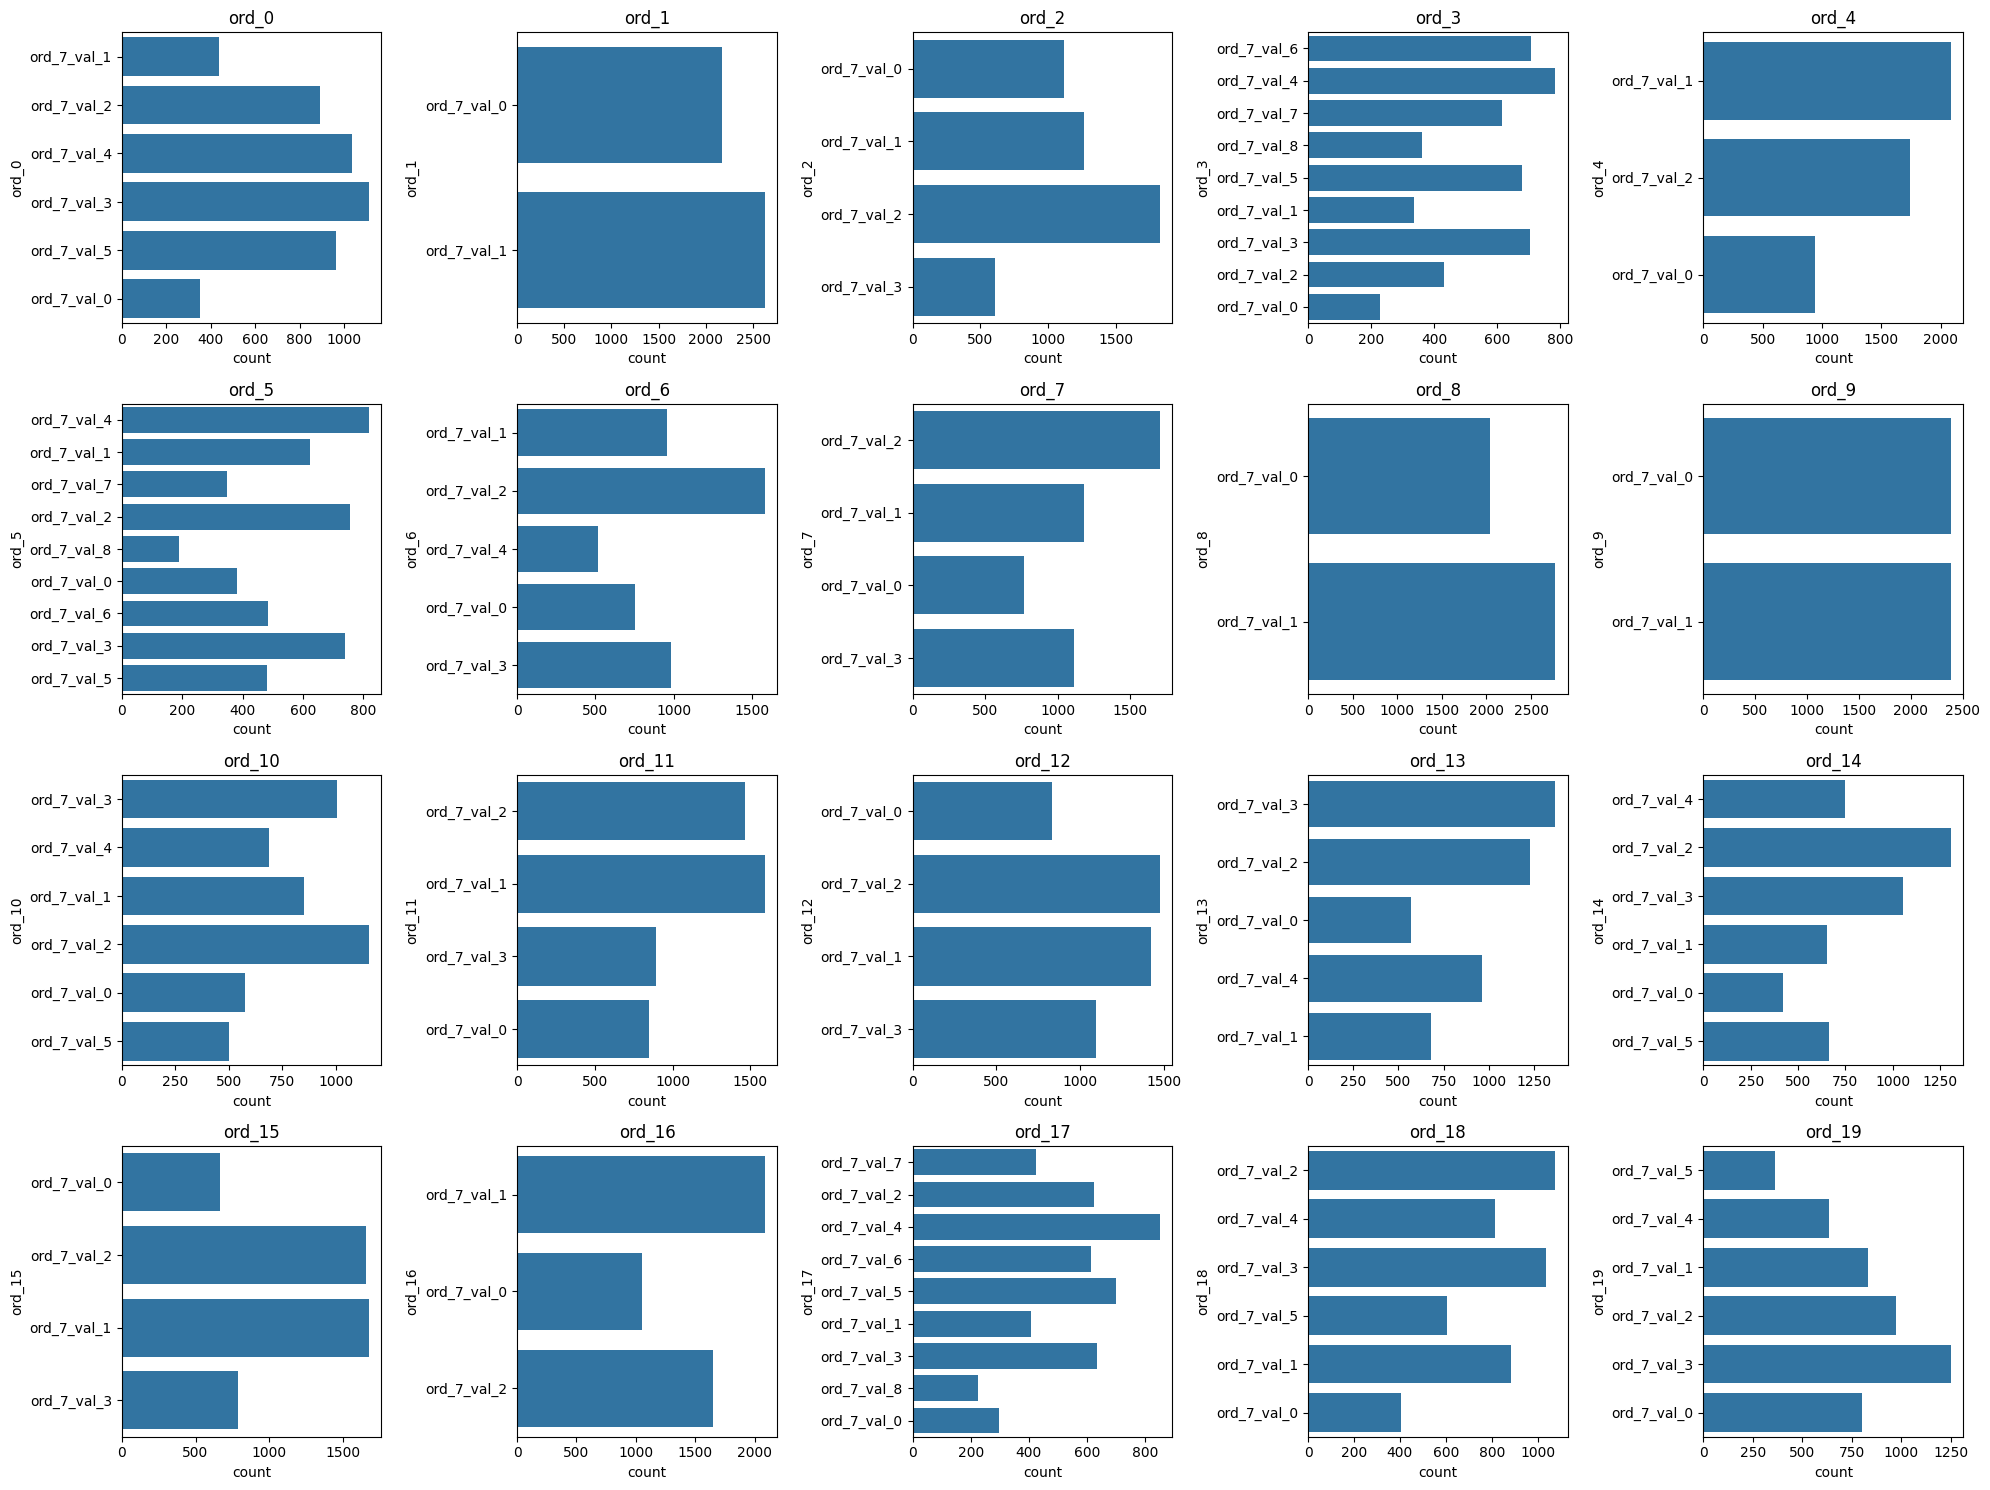

In [55]:
ordinal_features_mask = [col for col in train_data.columns if 'ord' in col]
ordinal_features = train_data[ordinal_features_mask]
plt.figure(figsize=(20, 15))
for i,col in enumerate(ordinal_features_mask):
    plt.subplot(4,5, i+1)
    sns.countplot(ordinal_features[col])
    plt.title(col)
plt.tight_layout()
plt.show()


In [56]:
ordinal_encoder = OrdinalEncoder(
    handle_unknown="use_encoded_value", 
    unknown_value=-1,
    encoded_missing_value= -1,
    dtype = int
)
train_data[ordinal_features_mask] = ordinal_encoder.fit_transform(train_data[ordinal_features_mask])
test_data[ordinal_features_mask] = ordinal_encoder.transform(test_data[ordinal_features_mask])

train_data[ordinal_features_mask].head(15)

,ord_0,ord_1,ord_2,ord_3,ord_4,ord_5,ord_6,ord_7,ord_8,ord_9,ord_10,ord_11,ord_12,ord_13,ord_14,ord_15,ord_16,ord_17,ord_18,ord_19
0,1,0,0,6,1,4,1,2,-1,0,3,2,0,3,4,0,1,7,-1,5
1,2,1,-1,4,1,4,-1,1,-1,-1,3,1,2,2,2,2,1,-1,2,4
2,-1,1,1,-1,2,-1,-1,2,0,0,4,1,1,3,-1,-1,-1,2,2,4
3,1,1,1,-1,2,-1,2,-1,-1,-1,3,3,1,2,3,2,0,4,-1,4
4,4,-1,1,-1,2,1,-1,1,1,-1,1,2,1,3,3,1,2,4,2,1
5,1,1,2,-1,0,7,2,0,0,-1,2,1,2,2,3,2,-1,6,4,2
6,3,-1,2,7,-1,1,4,3,0,1,2,3,3,2,3,1,-1,6,3,3
7,5,1,1,6,2,1,0,2,0,-1,0,2,0,2,4,3,0,7,-1,2
8,-1,0,3,8,-1,1,1,2,-1,1,1,1,3,-1,2,1,0,5,2,3
9,1,1,1,-1,1,7,2,2,0,0,5,1,3,2,4,1,0,1,2,3


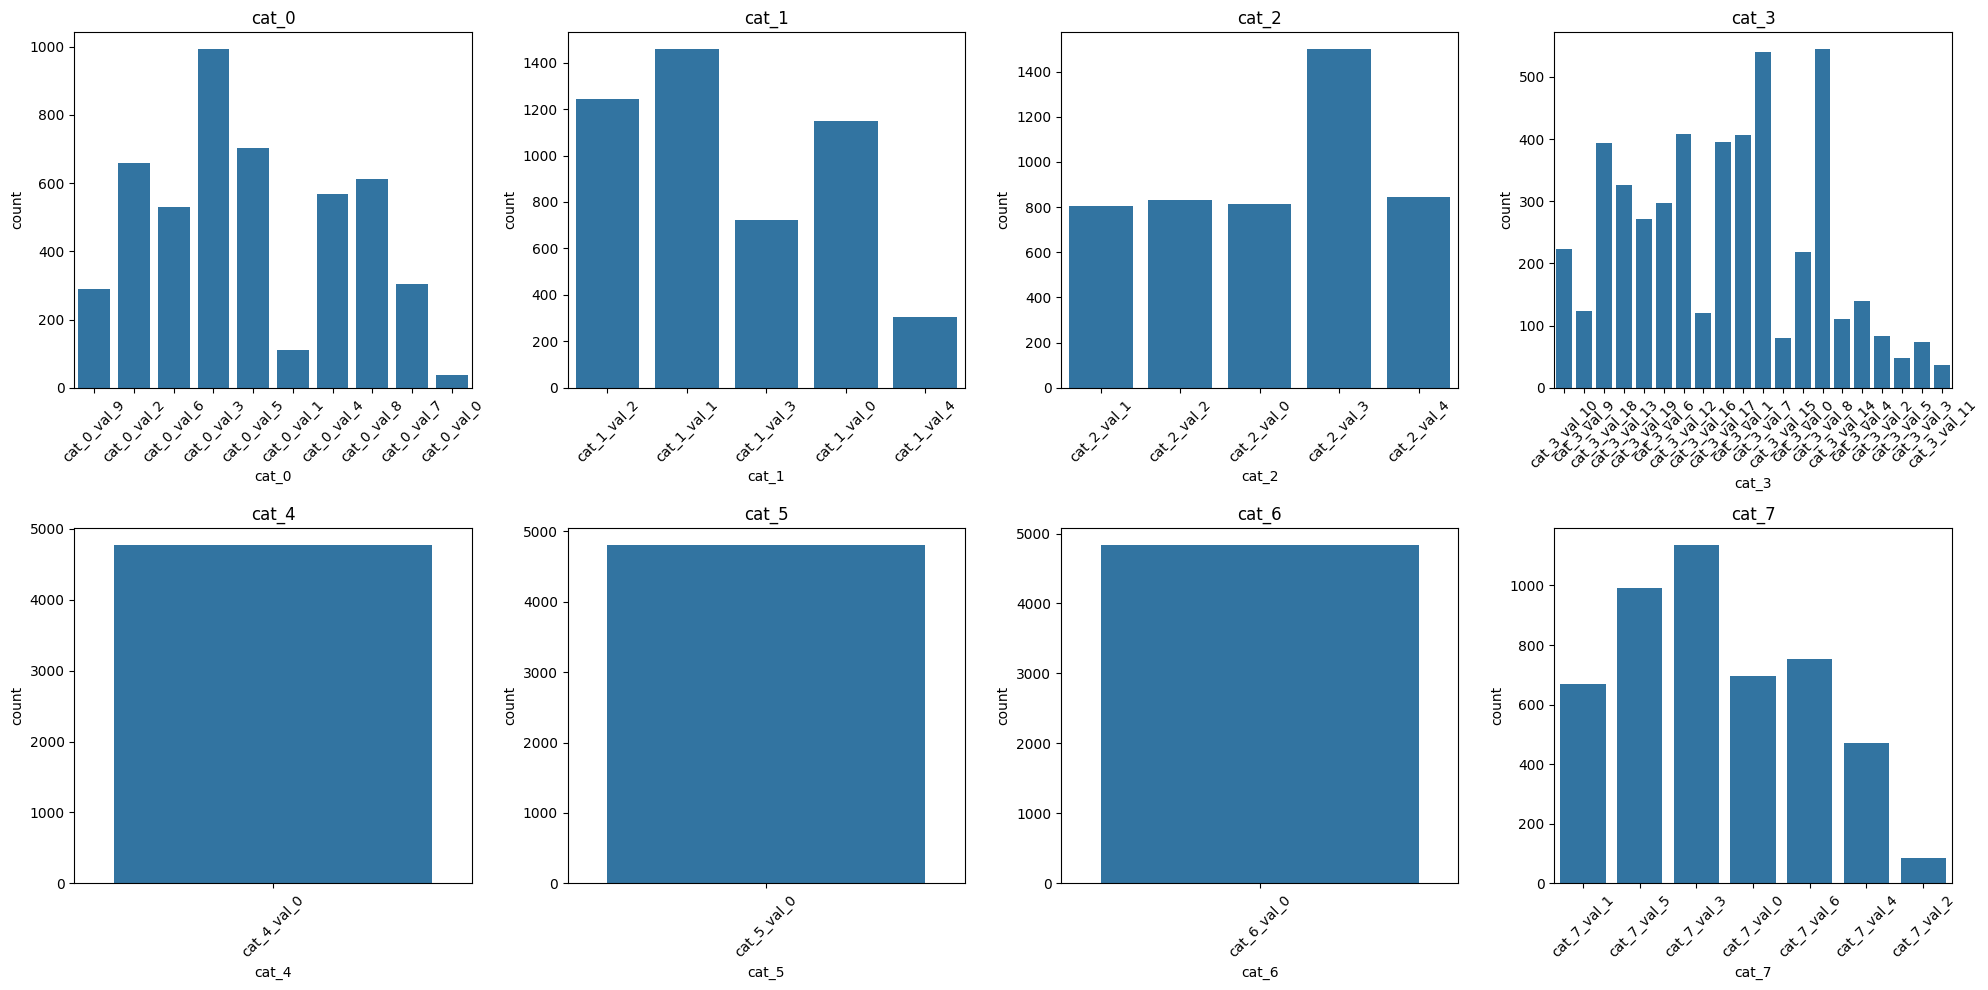

In [57]:
categorical_feautres_mask = [col for col in train_data.columns if 'cat' in col]
categorical_features = train_data[categorical_feautres_mask]
plt.figure(figsize=(20, 10))
for i, col in enumerate(categorical_feautres_mask):
    plt.subplot(2, 4, i + 1)
    sns.countplot(x = train_data[col])
    plt.xticks(rotation=45)
    plt.title(col)
plt.tight_layout()
plt.show()

In [58]:
print("cat_4 unique values:")
print(train_data['cat_4'].value_counts(dropna=False))
print("\ncat_5 unique values:") 
print(train_data['cat_5'].value_counts(dropna=False))
print("\ncat_6 unique values:")
print(train_data['cat_6'].value_counts(dropna=False))


train_data = train_data.drop(columns=['cat_4', 'cat_5', 'cat_6'])
test_data = test_data.drop(columns=['cat_4', 'cat_5', 'cat_6'])

categorical_features_mask = [col for col in train_data.columns if 'cat' in col]

train_data = pd.get_dummies(train_data, columns=categorical_features_mask, drop_first=True)
test_data = pd.get_dummies(test_data, columns=categorical_features_mask, drop_first=True)


cat_4 unique values:
cat_4
cat_4_val_0    4776
NaN            1224
Name: count, dtype: int64

cat_5 unique values:
cat_5
cat_5_val_0    4811
NaN            1189
Name: count, dtype: int64

cat_6 unique values:
cat_6
cat_6_val_0    4841
NaN            1159
Name: count, dtype: int64


In [59]:
print(train_data.isna().sum().sum())

0


### 3 — Train / Validation Split (local testing)

Tasks:
- Create a reproducible split and evaluate using R².
- Keep evaluation code separate from final training pipeline.

(Implement your code in the cell below.)

In [60]:
models = {
    "LinearRegression": {
        "model" : LinearRegression(),
        "params": {
            'fit_intercept': [True, False],
            'tol': [1e-4, 1e-3]
        }
    },
    "RandomForestRegressor": {
        "model": RandomForestRegressor(),
        "params": {
            'n_estimators': [10, 20, 50],
            'max_depth': [None, 10, 20],
            'min_samples_split': [2, 5, 10]
        }
    },
    "KNeighborsRegressor": {
        "model": KNeighborsRegressor(),
        "params": {
            'n_neighbors': [3, 5, 7],
            'weights': ['uniform', 'distance'],
            'p': [1, 2]
        }
    }
}

In [70]:
x_train = train_data.drop(columns=['target'])
y_train = train_data['target']
best_models = {}
for model, model_properties in models.items():
    grid_search = GridSearchCV(model_properties["model"], model_properties["params"], cv=5)
    grid_search.fit(x_train, y_train)
    best_models[model] = grid_search.best_estimator_
    avg_mse = -grid_search.best_score_
    print(f"Best parameters for {model}: {grid_search.best_params_}, Average MSE: {avg_mse}")
best_models

Best parameters for LinearRegression: {'fit_intercept': False, 'tol': 0.0001}, Average MSE: -0.283966988680337
Best parameters for RandomForestRegressor: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}, Average MSE: -0.7841663760508406
Best parameters for KNeighborsRegressor: {'n_neighbors': 7, 'p': 1, 'weights': 'distance'}, Average MSE: -0.7986617836767064


{'LinearRegression': LinearRegression(fit_intercept=False, tol=0.0001),
 'RandomForestRegressor': RandomForestRegressor(n_estimators=50),
 'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=7, p=1, weights='distance')}

### 4 — Model training

Tasks:
- Train chosen regression model(s) with fixed seeds.
- Document hyperparameters and training details.

(Implement your code in the cell below.)

In [71]:
SEED = 42
y_test = pd.read_csv("gt_test_dataset.csv")['value']
test_accuracy_per_model = {}
for model_name, model in best_models.items():
    model.fit(x_train, y_train)
    results = model.predict(test_data)
    mse = np.mean((results - y_test) ** 2)
    test_accuracy_per_model[model_name] = mse
test_accuracy_per_model



{'LinearRegression': np.float64(0.7404422502452694),
 'RandomForestRegressor': np.float64(0.2186896839645311),
 'KNeighborsRegressor': np.float64(0.19443299030758943)}